In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [13]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


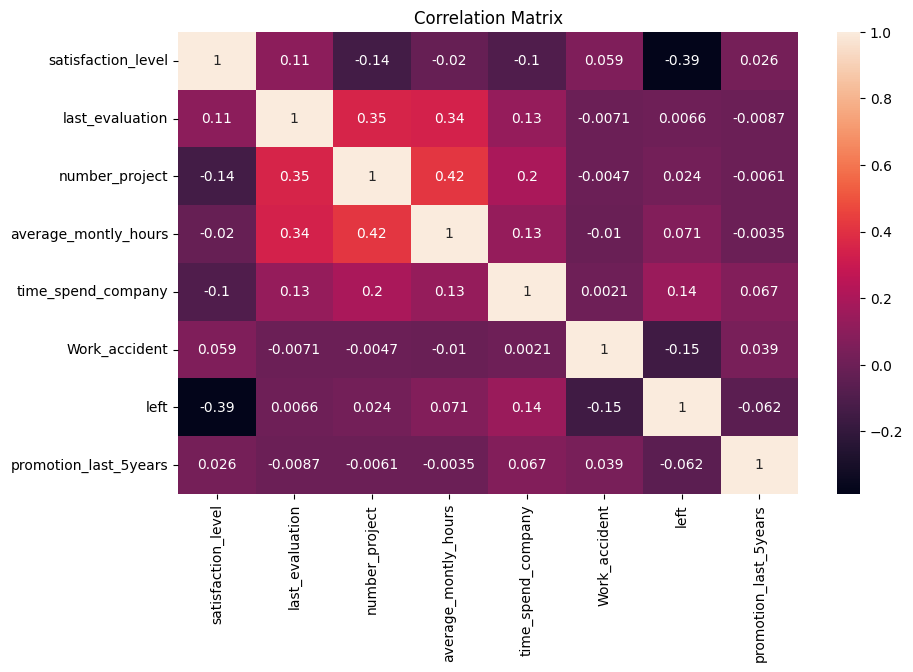

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

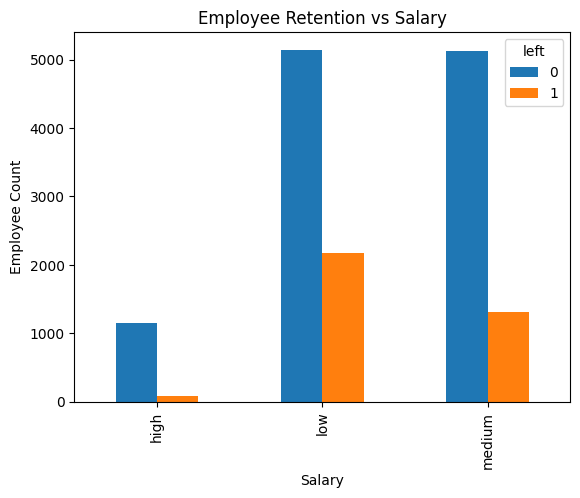

In [16]:
pd.crosstab(df.salary, df.left).plot(kind='bar')

plt.title("Employee Retention vs Salary")
plt.xlabel("Salary")
plt.ylabel("Employee Count")
plt.show()

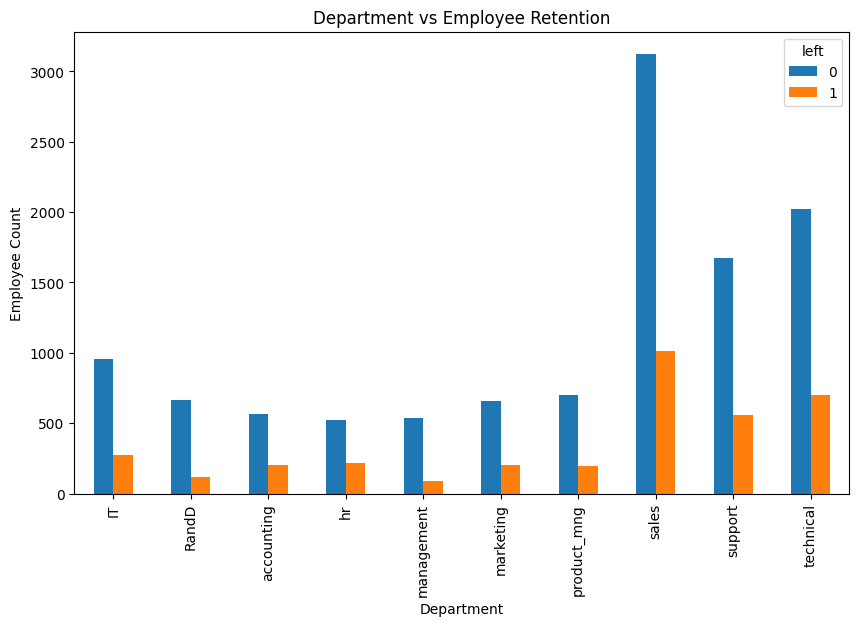

In [17]:
pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,6))

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.show()

In [18]:
df2 = df[['satisfaction_level','average_montly_hours','promotion_last_5years','Department','salary']]
df2.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,Department,salary
0,0.38,157,0,sales,low
1,0.80,262,0,sales,medium
2,0.11,272,0,sales,medium
3,0.72,223,0,sales,low
4,0.37,159,0,sales,low


In [20]:
department_dummies = pd.get_dummies(df2['Department'], prefix='dept')
salary_dummies = pd.get_dummies(df2['salary'], prefix='salary')

In [21]:
df3 = pd.concat([df2, department_dummies, salary_dummies], axis=1)
df3.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,Department,salary,dept_IT,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_high,salary_low,salary_medium
0,0.38,157,0,sales,low,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0.80,262,0,sales,medium,False,False,False,False,False,False,False,True,False,False,False,False,True
2,0.11,272,0,sales,medium,False,False,False,False,False,False,False,True,False,False,False,False,True
3,0.72,223,0,sales,low,False,False,False,False,False,False,False,True,False,False,False,True,False
4,0.37,159,0,sales,low,False,False,False,False,False,False,False,True,False,False,False,True,False


In [22]:
df3.drop(['Department','salary'], axis=1, inplace=True)
df3.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,dept_IT,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_high,salary_low,salary_medium
0,0.38,157,0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0.80,262,0,False,False,False,False,False,False,False,True,False,False,False,False,True
2,0.11,272,0,False,False,False,False,False,False,False,True,False,False,False,False,True
3,0.72,223,0,False,False,False,False,False,False,False,True,False,False,False,True,False
4,0.37,159,0,False,False,False,False,False,False,False,True,False,False,False,True,False


In [23]:
X = df3
y = df.left

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)